In [1]:
import pandas as pd

df = pd.read_csv("C:\Users\bhoom\Downloads\Telco-Customer-Churn.csv")

print(df.head())

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (657267596.py, line 3)

In [2]:
import pandas as pd

df = pd.read_csv("C:/Users/bhoom/Downloads/Telco-Customer-Churn.csv")

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df['TotalCharges'] = pd.to_numeric(
df['TotalCharges'],
errors='coerce'
)

In [6]:
df.fillna(df['TotalCharges'].median(),
inplace=True)

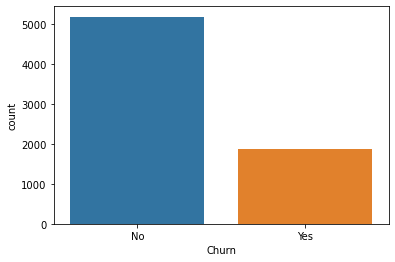

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.show()



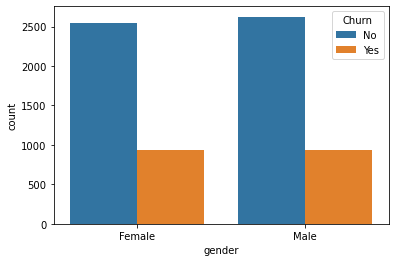

In [8]:
sns.countplot(
x='gender',
hue='Churn',
data=df
)
plt.show()

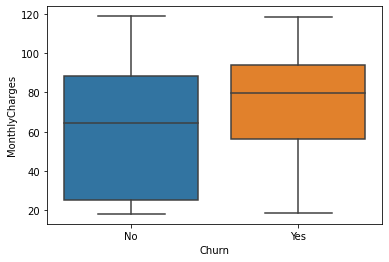

In [9]:
sns.boxplot(
x='Churn',
y='MonthlyCharges',
data=df
)
plt.show()

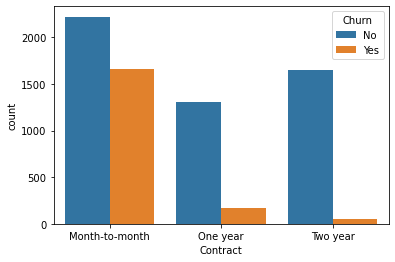

In [10]:
sns.countplot(
x='Contract',
hue='Churn',
data=df
)
plt.show()

In [11]:
df['Churn'] = df['Churn'].map({
'Yes':1,
'No':0
})

In [12]:
df = pd.get_dummies(
df,
drop_first=True
)

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)

y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(
X_train,
y_train
)

LogisticRegression()

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score

accuracy_score(
y_test,
y_pred
)

0.8190205819730305

In [17]:
from sklearn.metrics import confusion_matrix

confusion_matrix(
y_test,
y_pred
)

array([[943,  93],
       [162, 211]], dtype=int64)

In [18]:
from sklearn.metrics import classification_report

print(
classification_report(
y_test,
y_pred
)
)

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [19]:
importance = pd.DataFrame({
'Feature':X.columns,
'Coefficient':model.coef_[0]
})

importance.sort_values(
by='Coefficient',
ascending=False
)

,Feature,Coefficient
7052,InternetService_Fiber optic,0.449798
7070,PaymentMethod_Electronic check,0.419878
7068,PaperlessBilling_Yes,0.377000
0,SeniorCitizen,0.277440
7051,MultipleLines_Yes,0.227821
...,...,...
7071,PaymentMethod_Mailed check,-0.261873
7049,PhoneService_Yes,-0.266753
7067,Contract_Two year,-0.389149
7061,TechSupport_Yes,-0.515524


In [20]:
import shap

explainer = shap.Explainer(
model,
X_train
)

shap_values = explainer(
X_test
)

shap.plots.bar(
shap_values
)

ModuleNotFoundError: No module named 'shap'

In [21]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


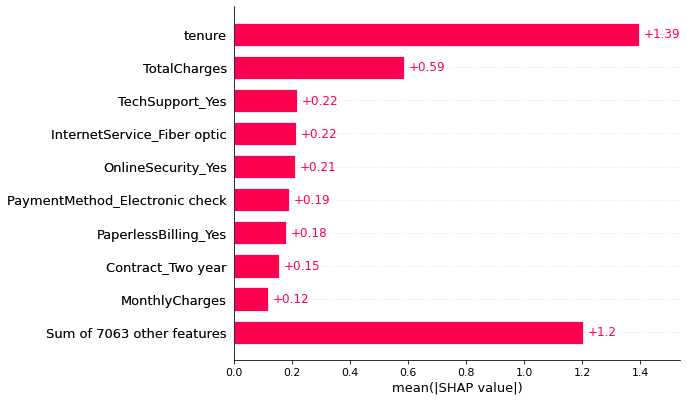

In [22]:
import shap
explainer = shap.Explainer(
model,
X_train
)
shap_values = explainer(
X_test
)
shap.plots.bar(
shap_values
)

In [23]:
probs = model.predict_proba(X)[:,1]

In [24]:
0.05
0.12
0.45
0.81
0.92

0.92

In [25]:
df['Churn_Probability']=probs

In [28]:
def segment_customer(prob):
    
  if prob < 0.20:
    return 'Loyal'
  elif prob < 0.60:
    return 'At Risk'
  else:
    return 'Dormant'

In [32]:
df['Customer_Segment']=df['Churn_Probability'].apply(segment_customer)

In [33]:
df['Customer_Segment'].value_counts()

Loyal      3683
At Risk    2368
Dormant     992
Name: Customer_Segment, dtype: int64

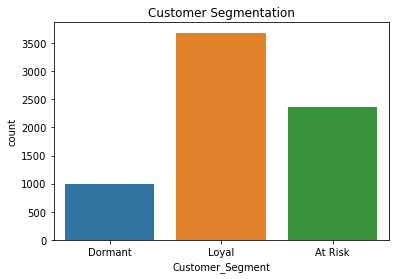

In [34]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.countplot(
x='Customer_Segment',
data=df
)
plt.title('Customer Segmentation')
plt.show()